In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('/content/train (1).csv')
data.head()

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,199.72.81.55,01/Jul/1995:00:00:01 -0400,GET,/history/apollo/,HTTP/1.0,200.0,6245.0
1,unicomp6.unicomp.net,01/Jul/1995:00:00:06 -0400,GET,/shuttle/countdown/,HTTP/1.0,200.0,3985.0
2,199.120.110.21,01/Jul/1995:00:00:09 -0400,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200.0,4085.0
3,burger.letters.com,01/Jul/1995:00:00:11 -0400,GET,/shuttle/countdown/liftoff.html,HTTP/1.0,304.0,0.0
4,199.120.110.21,01/Jul/1995:00:00:11 -0400,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200.0,4179.0


In [ ]:
data = pd.read_csv('/content/test (1).csv')
data.head()

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:00 -0400,GET,/ksc.html,HTTP/1.0,200.0,7087.0
1,internet-gw.watson.ibm.com,23/Aug/1995:00:00:05 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200.0,1292.0
2,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:06 -0400,GET,/images/ksclogo-medium.gif,HTTP/1.0,200.0,5866.0
3,internet-gw.watson.ibm.com,23/Aug/1995:00:00:08 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200.0,1625.0
4,internet-gw.watson.ibm.com,23/Aug/1995:00:00:10 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,404.0,0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data['request_src'].value_counts()

,count
request_src,
benny.westimg.com,186
150.18.48.11,167
asd01-14.dial.xs4all.nl,125
128.217.62.2,122
internet-gw.ford.com,105
...,...
gatekeeper.mitre.org,1
ppp1017.po.iijnet.or.jp,1
pm-gb1-122.coastalnet.com,1


In [ ]:
data['method'].value_counts()

,count
method,
GET,21274
HEAD,58
POST,2


In [ ]:
data['dest_path'].value_counts()

,count
dest_path,
/images/NASA-logosmall.gif,1420
/images/MOSAIC-logosmall.gif,1075
/images/USA-logosmall.gif,1072
/images/WORLD-logosmall.gif,1061
/images/ksclogo-medium.gif,1033
...,...
"/cgi-bin/imagemap/countdown69?286,291",1
"/cgi-bin/imagemap/countdown69?181,285",1
"/cgi-bin/imagemap/countdown69?182,280",1


In [ ]:
df = data.copy()
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z", errors='coerce' # Added errors='coerce' to handle parsing issues
)

df = df.set_index("timestamp")

df.head()

,request_src,method,dest_path,http_type,status,bytes
timestamp,,,,,,
1995-08-23 00:00:00-04:00,ix-mia1-02.ix.netcom.com,GET,/ksc.html,HTTP/1.0,200.0,7087.0
1995-08-23 00:00:05-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200.0,1292.0
1995-08-23 00:00:06-04:00,ix-mia1-02.ix.netcom.com,GET,/images/ksclogo-medium.gif,HTTP/1.0,200.0,5866.0
1995-08-23 00:00:08-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200.0,1625.0
1995-08-23 00:00:10-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,404.0,0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu nhanh
df_raw = pd.read_csv('/content/train (1).csv', usecols=['timestamp', 'request_src'], engine='c')

# 2. Xử lý thời gian và Timezone
time_format = "%d/%b/%Y:%H:%M:%S %z"
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format=time_format, cache=True)
df_raw.set_index('timestamp', inplace=True)

# 3. Gom nhóm theo khung thời gian (Ví dụ 1 phút)
# Loại bỏ timezone để tránh lỗi tương thích với các thư viện statsmodels
df_1m = df_raw['request_src'].resample('1T').count().tz_localize(None)

/tmp/ipython-input-3562152538.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_1m = df_raw['request_src'].resample('1T').count().tz_localize(None)


Prophet

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np

df_raw = pd.read_csv('/content/train (1).csv', usecols=['timestamp', 'request_src'], engine='c')

time_format = "%d/%b/%Y:%H:%M:%S %z"
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format=time_format, cache=True)
df_raw.set_index('timestamp', inplace=True)

def prepare_data(df, freq):
    res = df['request_src'].resample(freq).count().reset_index()
    res.columns = ['ds', 'y']
    res['ds'] = res['ds'].dt.tz_localize(None)
    return res

df_1m = prepare_data(df_raw, '1min')
df_5m = prepare_data(df_raw, '5min')
df_15m = prepare_data(df_raw, '15min')

print("Data prepared for 1m, 5m, and 15m timeframes.")

Data prepared for 1m, 5m, and 15m timeframes.


In [ ]:
all_forecasts = {}
datasets = {'1m': df_1m, '5m': df_5m, '15m': df_15m}

for name, df in datasets.items():

    model = Prophet(
        changepoint_prior_scale=0.8,
        n_changepoints=100,
        daily_seasonality=True,
        interval_width=0.95
    )
    model.add_seasonality(name='custom_spike', period=1/24, fourier_order=25)
    train_data = df.tail(2000)
    model.fit(train_data)
    forecast = model.predict(train_data)
    all_forecasts[name] = (train_data, forecast)

print("Prophet models trained and forecasts generated for all timeframes.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.


Prophet models trained and forecasts generated for all timeframes.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
from prophet import Prophet

def mean_absolute_percentage_error(y_true, y_pred):
    # Convert Series to numpy arrays to avoid index alignment issues
    y_true_np = y_true.to_numpy()
    y_pred_np = y_pred.to_numpy()

    # Filter out zero values in y_true to avoid division by zero
    non_zero_mask = y_true_np != 0
    if non_zero_mask.sum() == 0:
        return np.nan # Return NaN if all y_true are zero
    return np.mean(np.abs((y_true_np[non_zero_mask] - y_pred_np[non_zero_mask]) / y_true_np[non_zero_mask])) * 100

def plot_forecast_results(name, actual_data, predicted_data, rmse, zoom=200):
    plt.figure(figsize=(15, 6))
    plt.plot(actual_data['ds'], actual_data['y'], label='Thực tế (Actual)', color='blue', alpha=0.5)
    plt.plot(predicted_data['ds'], predicted_data['yhat'], label='Dự báo (Prophet)', color='red', linestyle='-', linewidth=1)
    plt.title(f"So sánh Thực tế vs Dự báo {name} (RMSE: {rmse:.2f})")
    plt.xlabel("Timestamp")
    plt.ylabel("Request Count")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.


Timeframe  | RMSE       | MSE        | MAE        | MAPE (%)  
------------------------------------------------------------
Processing timeframe: 1m
1m         | 16.94      | 287.10     | 12.56      | 30.57     %


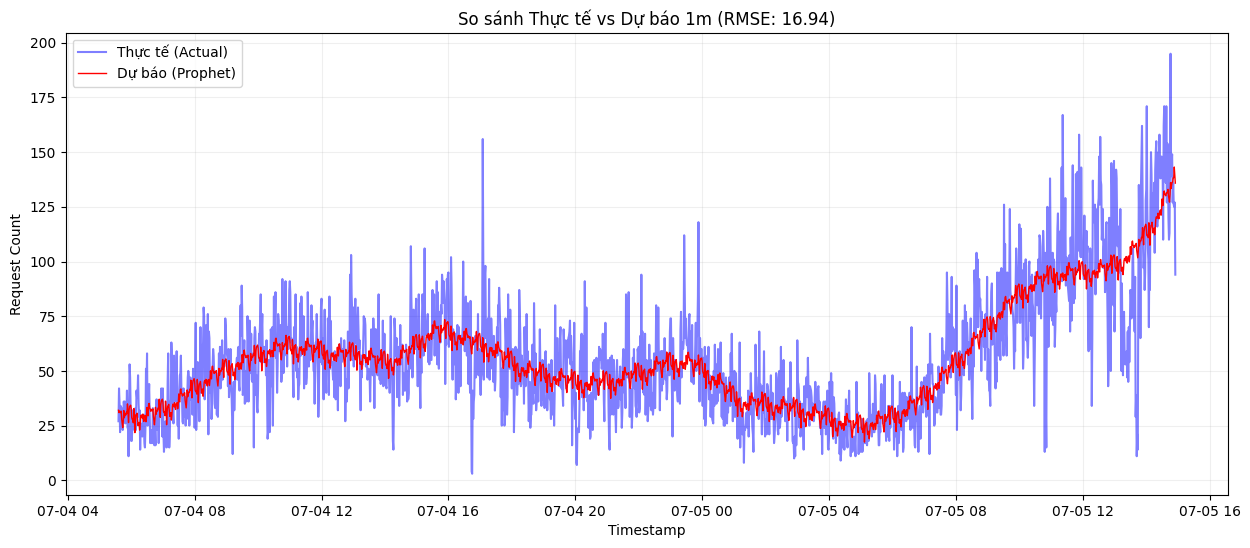

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.




Processing timeframe: 5m
5m         | 54.78      | 3000.91    | 39.68      | 37.64     %


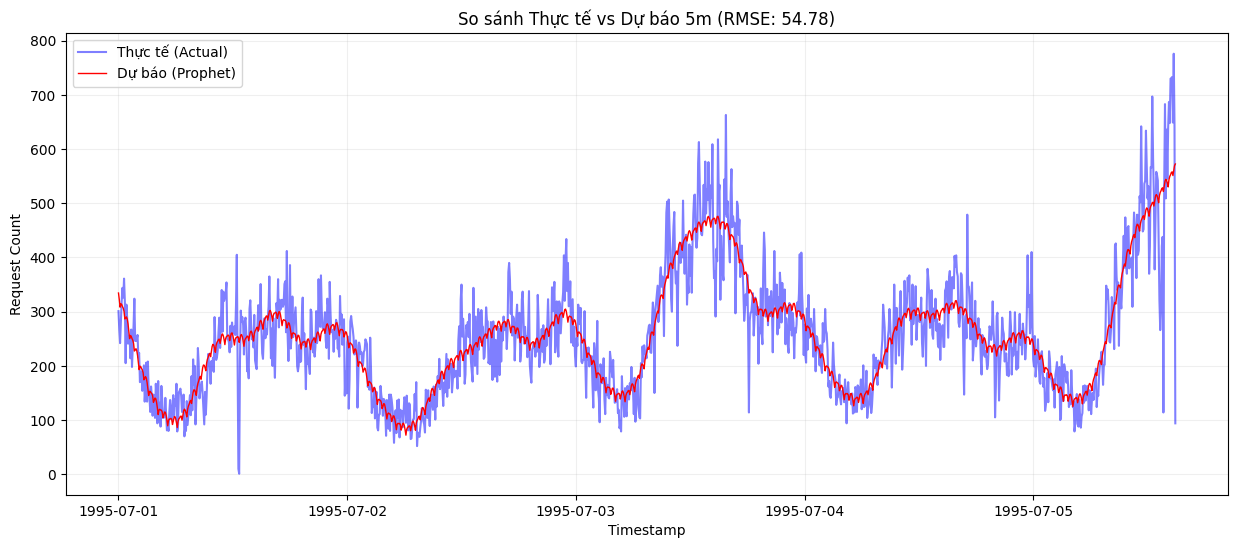



Processing timeframe: 15m


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.


15m        | 121.05     | 14652.08   | 89.06      | 12.80     %


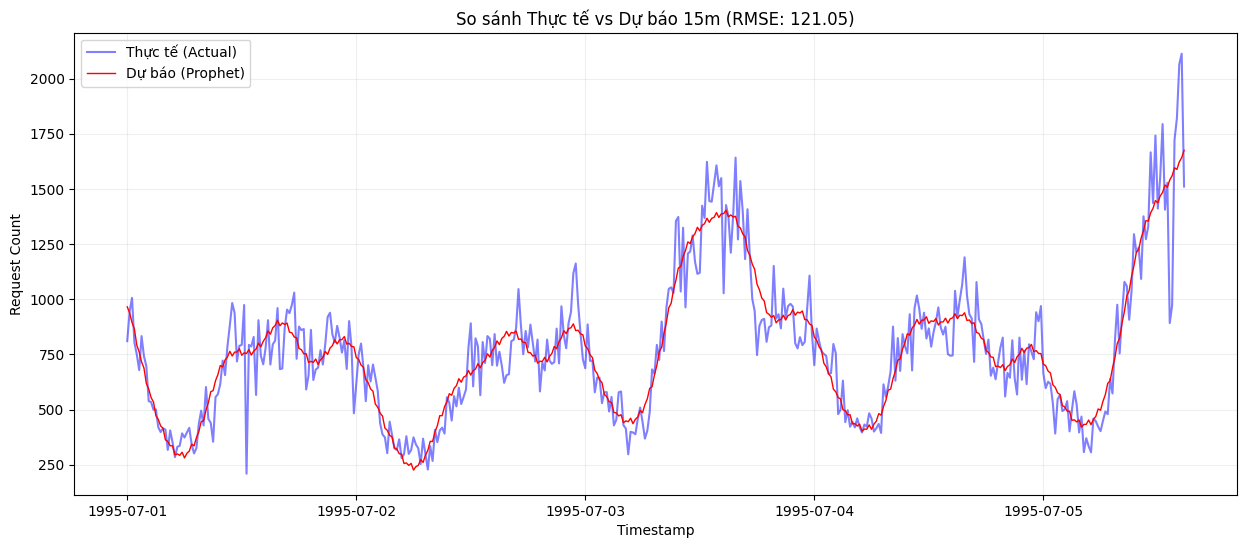




Bảng tổng hợp kết quả:


,Timeframe,RMSE,MSE,MAE,MAPE (%)
0,1m,16.944008,287.099423,12.560249,30.573623
1,5m,54.780553,3000.908934,39.679928,37.639677
2,15m,121.045774,14652.079500,89.060313,12.796341


In [ ]:
all_forecasts = {}
metrics_summary = []
datasets = {'1m': df_1m, '5m': df_5m, '15m': df_15m}

print(f"{'Timeframe':<10} | {'RMSE':<10} | {'MSE':<10} | {'MAE':<10} | {'MAPE (%)':<10}")
print("-" * 60)

for name, df in datasets.items():
    print(f"Processing timeframe: {name}")

    # 1. Train Prophet model
    model = Prophet(
        changepoint_prior_scale=0.8,
        n_changepoints=100,
        daily_seasonality=True,
        interval_width=0.95
    )
    model.add_seasonality(name='custom_spike', period=1/24, fourier_order=25)
    train_data = df.tail(2000) # Use the last 2000 data points for training as before
    model.fit(train_data)
    forecast = model.predict(train_data)
    all_forecasts[name] = (train_data, forecast)

    # 2. Evaluate metrics
    y_true = train_data['y']
    y_pred = forecast['yhat']

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    metrics_summary.append({
        'Timeframe': name,
        'RMSE': rmse,
        'MSE': mse,
        'MAE': mae,
        'MAPE (%)': mape
    })
    print(f"{name:<10} | {rmse:<10.2f} | {mse:<10.2f} | {mae:<10.2f} | {mape:<10.2f}%")

    # 3. Plot results
    plot_forecast_results(name, train_data, forecast, rmse)
    print("\n")

# Display overall metrics summary
df_metrics = pd.DataFrame(metrics_summary)
print("\nBảng tổng hợp kết quả:")
display(df_metrics)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
    # Convert Series to numpy arrays to avoid index alignment issues
    y_true_np = y_true.to_numpy()
    y_pred_np = y_pred.to_numpy()

    # Filter out zero values in y_true to avoid division by zero
    non_zero_mask = y_true_np != 0
    if non_zero_mask.sum() == 0:
        return np.nan # Or handle as appropriate if all y_true are zero
    return np.mean(np.abs((y_true_np[non_zero_mask] - y_pred_np[non_zero_mask]) / y_true_np[non_zero_mask])) * 100

metrics_summary = []

print(f"{'Timeframe':<10} | {'RMSE':<10} | {'MSE':<10} | {'MAE':<10} | {'MAPE (%)':<10}")
print("-" * 60)

# Ensure all_forecasts is populated by running the Prophet training cells first
if 'all_forecasts' not in globals() or not all_forecasts:
    print("Error: 'all_forecasts' is not defined or empty. Please run the Prophet model training cells first.")
else:
    for timeframe in ['1m', '5m', '15m']:
        if timeframe not in all_forecasts:
            continue

        actual, pred = all_forecasts[timeframe]

        y_true = actual['y']
        y_pred = pred['yhat']

        # Calculate MSE (Mean Squared Error)
        mse = mean_squared_error(y_true, y_pred)

        # Calculate RMSE (Root Mean Squared Error)
        rmse = np.sqrt(mse)

        # Calculate MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_true, y_pred)

        # Calculate MAPE (Mean Absolute Percentage Error)
        mape = mean_absolute_percentage_error(y_true, y_pred)

        # Store results
        metrics_summary.append({
            'Timeframe': timeframe,
            'RMSE': rmse,
            'MSE': mse,
            'MAE': mae,
            'MAPE (%)': mape
        })

        print(f"{timeframe:<10} | {rmse:<10.2f} | {mse:<10.2f} | {mae:<10.2f} | {mape:<10.2f}%\n")

    # Convert to DataFrame for better presentation
    df_metrics = pd.DataFrame(metrics_summary)
    print("\nBảng tổng hợp kết quả:")
    display(df_metrics)